# 🧬 AlphaGenome Tools Example

This notebook demonstrates how to run **AlphaGenome** for genomic interval prediction, variant-effect prediction, variant scoring, interval scoring, and in-silico mutagenesis.

Examples reproduce figures from the [AlphaGenome paper](https://www.nature.com/articles/s41586-025-10014-0) and [quick-start notebook](https://colab.research.google.com/github/google-deepmind/alphagenome_research/blob/main/colabs/quick_start.ipynb).

## 📖 What is AlphaGenome?

[AlphaGenome](https://github.com/google-deepmind/alphagenome_research) is a multi-task genomic foundation model from Google DeepMind that predicts regulatory signals, splicing, and 3D contact maps from DNA sequence at single base-pair resolution.

### Key Features:
- 🧪 **Interval prediction** — Predict regulatory outputs (ATAC, CAGE, RNA-seq, etc.) over a genomic region
- 🧬 **Variant-effect prediction** — Compare reference vs alternate allele predictions
- 📏 **Variant scoring** — Score variants with recommended variant scorers (tidy DataFrame output)
- 📊 **Interval scoring** — Score intervals with recommended interval scorers
- 🔬 **In-silico mutagenesis** — Saturate-mutate a sub-interval and score each mutation
- 🧱 **Isolated runtime** — Runs in a standalone `EnvManager` venv with JAX + GPU

### Supported context lengths:
- **1,048,576 bp** (1 Mb — recommended)
- **524,288 bp** (500 Kb)
- **131,072 bp** (100 Kb)
- **16,384 bp** (16 Kb)
- **2,048 bp** (2 Kb)

Interval-based tools auto-resize to the nearest supported length if needed.

## 📦 Imports

## Input/Output Schema

### Interval Prediction

#### `AlphaGenomePredictIntervalInput`
| Field | Type | Description |
|-------|------|-------------|
| chromosome | str | Chromosome identifier, e.g. 'chr1' |
| interval_start | int | Interval start (0-based, inclusive) |
| interval_end | int | Interval end (0-based, exclusive) |

#### `AlphaGenomePredictIntervalConfig`
| Field | Type | Default | Description |
|-------|------|---------|-------------|
| model_version | str | "all_folds" | AlphaGenome Hugging Face model version |
| requested_outputs | List[OutputTypeName] | *(required)* | Output type names to request (e.g. ATAC, CAGE, DNASE, RNA_SEQ, CHIP_HISTONE, CHIP_TF, SPLICE_SITES, SPLICE_SITE_USAGE, SPLICE_JUNCTIONS, CONTACT_MAPS, PROCAP) |
| ontology_terms | Optional[List[str]] | None | Optional ontology term filters (e.g. 'EFO:0001187' for HepG2) |
| organism | Literal["human", "mouse"] | "human" | Organism for predictions |
| device | str | "cuda" | Device to run inference on |

### Variant-Effect Prediction

#### `AlphaGenomePredictVariantInput`
| Field | Type | Description |
|-------|------|-------------|
| chromosome | str | Chromosome identifier, e.g. 'chr1' |
| interval_start | int | Interval start (0-based, inclusive) |
| interval_end | int | Interval end (0-based, exclusive) |
| variant_position | int | Variant genomic position (0-based) |
| reference_bases | str | Reference allele, e.g. 'A' or 'AC' |
| alternate_bases | str | Alternate allele, e.g. 'G' or 'GTT' |

#### `AlphaGenomePredictVariantConfig`
Same fields as `AlphaGenomePredictIntervalConfig`.

### Raw Sequence Prediction

#### `AlphaGenomePredictSequenceInput`
| Field | Type | Description |
|-------|------|-------------|
| sequence | str | Raw DNA sequence for prediction (A/C/G/T/N characters) |

#### `AlphaGenomePredictSequenceConfig`
Same fields as `AlphaGenomePredictIntervalConfig`.

### Predict Output (shared by interval, variant, and sequence prediction)

#### `AlphaGenomePredictOutput`
| Field | Type | Description |
|-------|------|-------------|
| chromosome | str | Chromosome identifier |
| interval_start | int | Interval start (0-based) |
| interval_end | int | Interval end (0-based, exclusive) |
| requested_outputs | List[str] | Output types requested |
| result | Dict[str, Any] | Serialized AlphaGenome prediction payload |
| variant | Optional[Dict[str, Any]] | Variant metadata (variant predictions only) |

### Variant Scoring

#### `AlphaGenomeScoreVariantInput`
Same fields as `AlphaGenomePredictVariantInput`.

#### `AlphaGenomeScoreVariantConfig`
| Field | Type | Default | Description |
|-------|------|---------|-------------|
| model_version | str | "all_folds" | AlphaGenome Hugging Face model version |
| variant_scorers | Optional[List[VariantScorerName]] | None | Scorer names to use (None uses all recommended scorers) |
| organism | Literal["human", "mouse"] | "human" | Organism for predictions |
| device | str | "cuda" | Device to run inference on |

### Interval Scoring

#### `AlphaGenomeScoreIntervalInput`
Same fields as `AlphaGenomePredictIntervalInput`.

#### `AlphaGenomeScoreIntervalConfig`
| Field | Type | Default | Description |
|-------|------|---------|-------------|
| model_version | str | "all_folds" | AlphaGenome Hugging Face model version |
| interval_scorers | Optional[List[Literal["RNA_SEQ"]]] | None | Scorer names to use (None uses all recommended scorers) |
| organism | Literal["human", "mouse"] | "human" | Organism for predictions |
| device | str | "cuda" | Device to run inference on |

### In-Silico Mutagenesis (ISM)

#### `AlphaGenomeScoreISMInput`
| Field | Type | Default | Description |
|-------|------|---------|-------------|
| chromosome | str | *(required)* | Chromosome identifier, e.g. 'chr1' |
| interval_start | int | *(required)* | Interval start (0-based, inclusive) |
| interval_end | int | *(required)* | Interval end (0-based, exclusive) |
| ism_interval_start | int | *(required)* | ISM sub-interval start (0-based, inclusive) |
| ism_interval_end | int | *(required)* | ISM sub-interval end (0-based, exclusive) |
| variant_position | Optional[int] | None | Optional existing variant position for ISM context (0-based) |
| reference_bases | Optional[str] | None | Optional existing variant reference allele |
| alternate_bases | Optional[str] | None | Optional existing variant alternate allele |

#### `AlphaGenomeScoreISMConfig`
Same fields as `AlphaGenomeScoreVariantConfig`.

### Score Output (shared by variant scoring, interval scoring, and ISM)

#### `AlphaGenomeScoreOutput`
| Field | Type | Description |
|-------|------|-------------|
| scores | List[Dict[str, Any]] | Tidy score records (one per scorer-track-gene combination). Each dict contains keys such as variant_id, scored_interval, gene_id, gene_name, output_type, variant_scorer/interval_scorer, track_name, raw_score, etc. |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

from bio_programming.bio_tools.tools.sequence_scoring.alphagenome import (
    AlphaGenomePredictIntervalInput,
    AlphaGenomePredictVariantInput,
    AlphaGenomePredictSequenceInput,
    AlphaGenomeScoreVariantInput,
    AlphaGenomeScoreISMInput,
    AlphaGenomeScoreIntervalInput,
    AlphaGenomePredictIntervalConfig,
    AlphaGenomePredictVariantConfig,
    AlphaGenomePredictSequenceConfig,
    AlphaGenomeScoreVariantConfig,
    AlphaGenomeScoreIntervalConfig,
    AlphaGenomeScoreISMConfig,
    run_alphagenome_predict_interval,
    run_alphagenome_predict_variant,
    run_alphagenome_predict_sequence,
    run_alphagenome_score_variant,
    run_alphagenome_score_interval,
    run_alphagenome_score_ism_variants,
)

## 🎨 Plotting helper

A small utility to plot serialized AlphaGenome track predictions.

Our tools return predictions as JSON-serialized dicts (not native `TrackData` objects), so we use `matplotlib` directly rather than the upstream `plot_components` from alphagenome.

In [2]:
# Use a clean plot style
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.family": "sans-serif",
})


def plot_tracks(
    predictions: dict,
    track_keys: list[str],
    output_start: int,
    output_end: int,
    chromosome: str = "",
    colors: list[str] | None = None,
    labels: list[str] | None = None,
    filled: list[bool] | None = None,
    fig_width: float = 14,
    track_height: float = 2.5,
    title: str | None = None,
):
    """Plot one or more serialized AlphaGenome track predictions."""
    n = len(track_keys)
    if colors is None:
        cmap = plt.colormaps["viridis"]
        colors = [mcolors.rgb2hex(cmap(i)) for i in np.linspace(0.15, 0.85, n)]
    if labels is None:
        labels = [k.upper().replace("_", " ") for k in track_keys]
    if filled is None:
        filled = [True] * n

    fig, axes = plt.subplots(
        n, 1, figsize=(fig_width, track_height * n), sharex=True, squeeze=False
    )

    for idx, (ax, key, color, label, fill) in enumerate(
        zip(axes[:, 0], track_keys, colors, labels, filled)
    ):
        track_data = predictions.get(key)
        if track_data is None:
            ax.text(0.5, 0.5, f"{label} — not available",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="grey", style="italic")
            ax.set_ylabel(label)
            continue

        values = np.array(track_data["values"])
        signal = values.mean(axis=-1) if values.ndim == 2 else values
        bp = np.linspace(output_start, output_end, len(signal))

        if fill:
            ax.fill_between(bp, signal, alpha=0.55, color=color, linewidth=0)
            ax.plot(bp, signal, color=color, linewidth=0.6, alpha=0.85)
        else:
            ax.plot(bp, signal, color=color, linewidth=0.7, alpha=0.9)
        ax.set_ylabel(label)
        ax.set_xlim(output_start, output_end)

    region = f"{chromosome}:{output_start:,}-{output_end:,}" if chromosome else ""
    axes[-1, 0].set_xlabel(f"Genomic position (bp)\n{region}")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()


def plot_variant_overlay(
    variant_result,
    requested_outputs: list[str],
    ref_color: str = "dimgrey",
    alt_color: str = "red",
    fig_width: float = 14,
    track_height: float = 3.0,
    title: str | None = None,
):
    """Plot overlaid REF vs ALT predictions for a variant-effect result."""
    variant_preds = variant_result.result.get("predictions", {})
    ref_preds = variant_preds.get("reference", {})
    alt_preds = variant_preds.get("alternate", {})
    variant_pos = variant_result.variant["position"]
    output_start = variant_result.interval_start
    output_end = variant_result.interval_end

    n = len(requested_outputs)
    fig, axes = plt.subplots(
        n, 1, figsize=(fig_width, track_height * n), sharex=True, squeeze=False
    )

    for ax, output_name in zip(axes[:, 0], requested_outputs):
        track_key = output_name.lower()
        ref_data = ref_preds.get(track_key)
        alt_data = alt_preds.get(track_key)
        if ref_data is None or alt_data is None:
            ax.text(0.5, 0.5, f"{output_name} — not available",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="grey", style="italic")
            ax.set_ylabel(output_name.replace("_", " "))
            continue

        ref_vals = np.array(ref_data["values"])
        alt_vals = np.array(alt_data["values"])
        ref_signal = ref_vals.mean(axis=-1) if ref_vals.ndim == 2 else ref_vals
        alt_signal = alt_vals.mean(axis=-1) if alt_vals.ndim == 2 else alt_vals

        bp = np.linspace(output_start, output_end, len(ref_signal))
        ax.plot(bp, ref_signal, color=ref_color, alpha=0.85, linewidth=0.7, label="REF")
        ax.plot(bp, alt_signal, color=alt_color, alpha=0.75, linewidth=0.7, label="ALT")
        ax.axvline(
            variant_pos, color="#333333", linestyle="--", alpha=0.5,
            linewidth=1.0, label="Variant",
        )
        ax.legend(loc="upper right", fontsize=8, framealpha=0.8, edgecolor="none")
        ax.set_ylabel(output_name.replace("_", " "))
        ax.set_xlim(output_start, output_end)

    region = f"{variant_result.chromosome}:{output_start:,}-{output_end:,}"
    axes[-1, 0].set_xlabel(f"Genomic position (bp)\n{region}")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

---
## 🧪 1. Interval Prediction (Figure 2a)

Reproduces **Figure 2a** from the AlphaGenome paper: multi-track predictions within a **1 Mb** region of human chromosome 19 (`chr19:10,587,331–11,635,907`) in the **HepG2** cell line.

### Configuration options:
- 🧠 **`requested_outputs`** — Output type names to predict (e.g. `ATAC`, `RNA_SEQ`, `CAGE`, `DNASE`, `CHIP_HISTONE`, `CHIP_TF`, `SPLICE_SITES`, `SPLICE_SITE_USAGE`, `SPLICE_JUNCTIONS`, `CONTACT_MAPS`, `PROCAP`)
- 🐭 **`organism`** — `human` or `mouse`
- 🏷️ **`ontology_terms`** — Optional ontology term filters (e.g. `EFO:0001187` for HepG2)

In [3]:
# Paper Figure 2a coordinates — chr19, 1 Mb window, HepG2 cell line
interval_inputs = AlphaGenomePredictIntervalInput(
    chromosome="chr19",
    interval_start=10_587_331,
    interval_end=11_635_907,
)

interval_config = AlphaGenomePredictIntervalConfig(
    requested_outputs=["RNA_SEQ", "ATAC", "DNASE", "CHIP_HISTONE", "CHIP_TF"],
    ontology_terms=["EFO:0001187"],  # HepG2
    organism="human",
)

interval_result = run_alphagenome_predict_interval(interval_inputs, interval_config)
print("Requested outputs:", interval_result.requested_outputs)
print("Result keys:", list(interval_result.result.get("predictions", {}).keys()))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 30802.72it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Requested outputs: ['RNA_SEQ', 'ATAC', 'DNASE', 'CHIP_HISTONE', 'CHIP_TF']
Result keys: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']


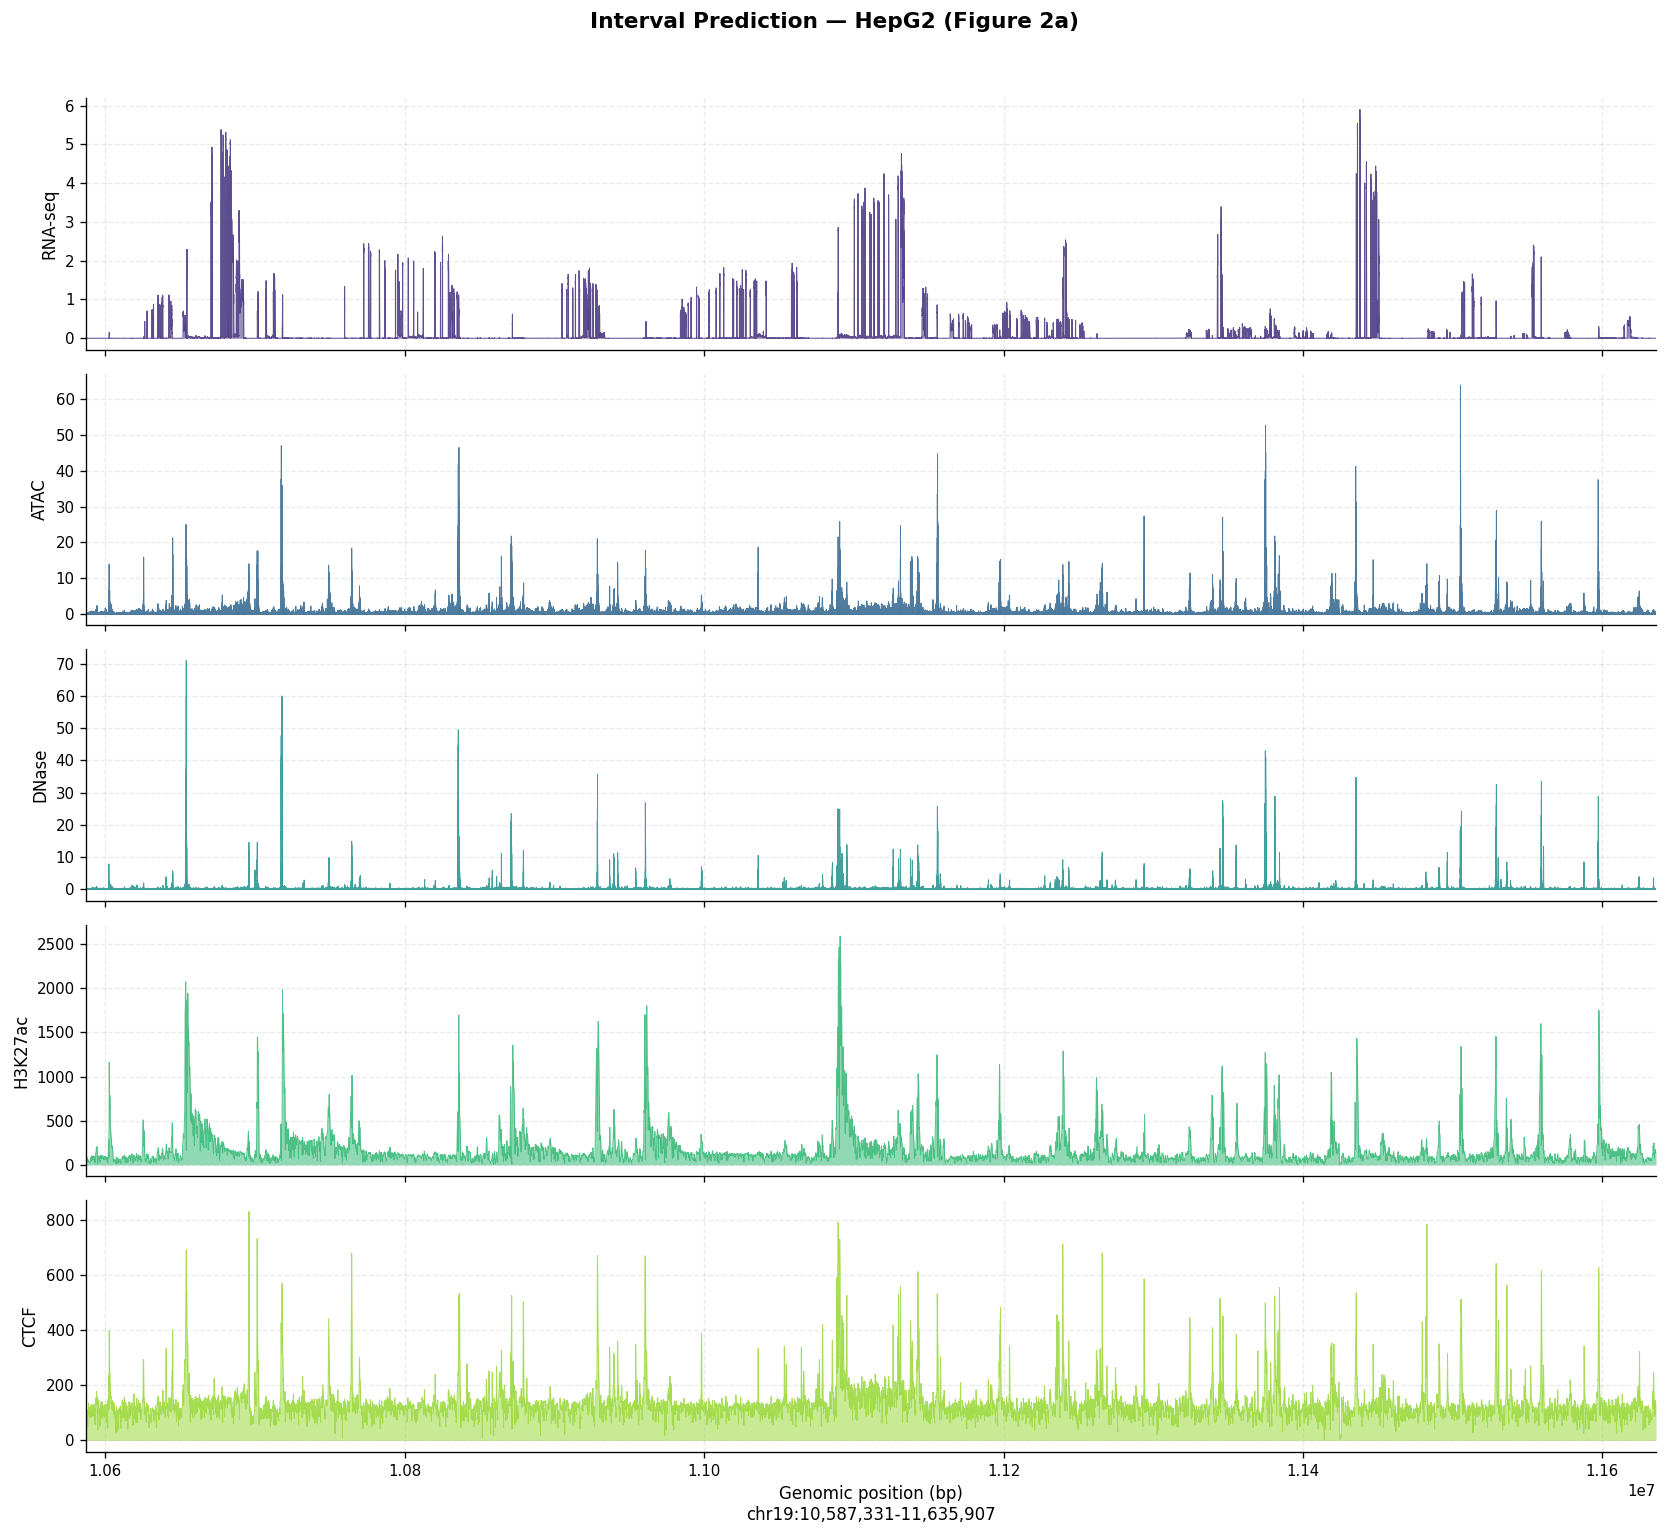

In [4]:
# 📈 Plot interval predictions — reproducing Figure 2a layout
plot_tracks(
    predictions=interval_result.result.get("predictions", {}),
    track_keys=["rna_seq", "atac", "dnase", "chip_histone", "chip_tf"],
    output_start=interval_result.interval_start,
    output_end=interval_result.interval_end,
    chromosome=interval_result.chromosome,
    labels=["RNA-seq", "ATAC", "DNase", "H3K27ac", "CTCF"],
    filled=[True, True, True, True, True],
    title="Interval Prediction — HepG2 (Figure 2a)",
)

---
## 🧬 2. Variant-Effect Prediction (Figure 3c)

Reproduces **Figure 3c** from the AlphaGenome paper: a variant in the *COL6A2* gene (`chr21:46,126,238 G>C`) that causes alternative splice junction formation by creating a new splicing donor and disrupting the extant one.

Predictions use a **1 Mb** context centered on the variant, with tracks filtered to **Aorta** tissue (`UBERON:0001496`). The plot overlays reference (**REF**, skyblue) and alternate (**ALT**, red) predictions for RNA-seq and splice-site usage, with a dashed line marking the variant position.

In [ ]:
# Paper Figure 3c coordinates — chr21:46,126,238 G>C (COL6A2), 1 Mb context, Aorta tissue
variant_inputs = AlphaGenomePredictVariantInput(
    chromosome="chr21",
    interval_start=45_601_950,
    interval_end=46_650_526,
    variant_position=46_126_238,
    reference_bases="G",
    alternate_bases="C",
)

variant_config = AlphaGenomePredictVariantConfig(
    requested_outputs=["RNA_SEQ", "SPLICE_SITE_USAGE"],
    ontology_terms=["UBERON:0001496"],  # Aorta
    organism="human",
)

variant_result = run_alphagenome_predict_variant(variant_inputs, variant_config)
print("Variant metadata:", variant_result.variant)
print("Result keys:", list(variant_result.result.get("predictions", {}).keys()))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 19373.23it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Variant metadata: {'position': 46126238, 'reference_bases': 'G', 'alternate_bases': 'C'}
Result keys: ['reference', 'alternate']


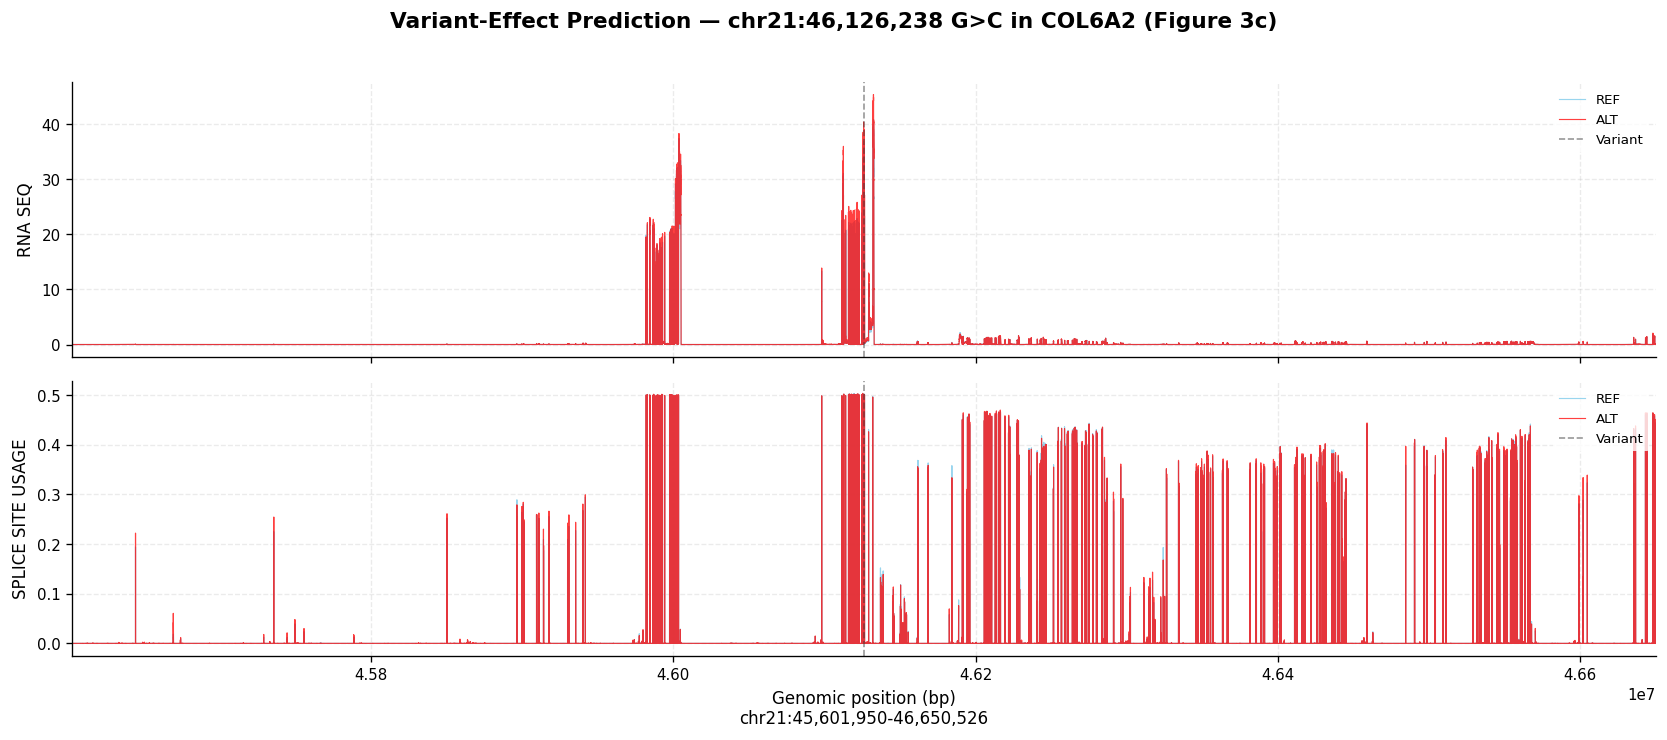

In [ ]:
# 📈 Plot variant-effect predictions — reproducing Figure 3c layout (REF vs ALT)
# Zoom into a 1.5 kb window around the variant (matching the paper figure)
plot_variant_overlay(
    variant_result,
    requested_outputs=variant_config.requested_outputs,
    ref_color="skyblue",
    alt_color="red",
    title="Variant-Effect Prediction — chr21:46,126,238 G>C in COL6A2 (Figure 3c)",
)

---
## 🔡 3. Raw Sequence Prediction

Run predictions from a raw DNA string (no reference genome lookup). The sequence length must match a supported context length.

In [7]:
# 2,048 bp from the APOE gene locus on chr19 (hg38: chr19:44,905,791-44,907,839)
apoe_seq = (
    "AGTCCTACTCAGCCCCAGCGGAGGTGAAGGACGTCCTTCCCCAGGAGCCGGTGAGAAGCGCAGTCGGGGGCACGGGGATGA"
    "GCTCAGGGGCCTCTAGAAAGAGCTGGGACCCTGGGAACCCCTGGCCTCCAGGTAGTCTCAGGAGAGCTACTCGGGGTCGGG"
    "CTTGGGGAGAGGAGGAGCGGGGGTGAGGCAAGCAGCAGGGGACTGGACCTGGGAAGGGCTGGGCAGCAGAGACGACCCGAC"
    "CCGCTAGAAGGTGGGGTGGGGAGAGCAGCTGGACTGGGATGTAAGCCATAGCAGGACTCCACGAGTTGTCACTATCATTTAT"
    "CGAGCACCTACTGGGTGTCCCCAGTGTCCTCAGATCTCCATAACTGGGGAGCCAGGGGCAGCGACACGGTAGCTAGCCGTCG"
    "ATTGGAGAACTTTAAAATGAGGACTGAATTAGCTCATAAATGGAACACGGCGCTTAACTGTGAGGTTGGAGCTTAGAATGTG"
    "AAGGGAGAATGAGGAATGCGAGACTGGGACTGAGATGGAACCGGCGGTGGGGAGGGGGTGGGGGGATGGAATTTGAACCCC"
    "GGGAGAGGAAGATGGAATTTTCTATGGAGGCCGACCTGGGGATGGGGAGATAAGAGAAGACCAGGAGGGAGTTAAATAGGGAA"
    "TGGGTTGGGGGCGGCTTGGTAAATGTGCTGGGATTAGGCTGTTGCAGATAATGCAACAAGGCTTGGAAGGCTAACCTGGGG"
    "TGAGGCCGGGTTGGGGCCGGGCTGGGGGTGGGAGGAGTCCTCACTGGCGGTTGATTGACAGTTTCTCCTTCCCCAGACTGGC"
    "CAATCACAGGCAGGAAGATGAAGGTTCTGTGGGCTGCGTTGCTGGTCACATTCCTGGCAGGTATGGGGGCGGGGCTTGCTC"
    "GGTTCCCCCCGCTCCTCCCCCTCTCATCCTCACCTCAACCTCCTGGCCCCATTCAGGCAGACCCTGGGCCCCCTCTTCTGAG"
    "GCTTCTGTGCTGCTTCCTGGCTCTGAACAGCGATTTGACGCTCTCTGGGCCTCGGTTTCCCCCATCCTTGAGATAGGAGTTA"
    "GAAGTTGTTTTGTTGTTGTTGTTTGTTGTTGTTGTTTTGTTTTTTTGAGATGAAGTCTCGCTCTGTCGCCCAGGCTGGAGT"
    "GCAGTGGCGGGATCTCGGCTCACTGCAAGCTCCGCCTCCCAGGTCCACGCCATTCTCCTGCCTCAGCCTCCCAAGTAGCTGG"
    "GACTACAGGCACATGCCACCACACCCGACTAACTTTTTTGTATTTTCAGTAGAGACGGGGTTTCACCATGTTGGCCAGGCTG"
    "GTCTGGAACTCCTGACCTCAGGTGATCTGCCCGTTTCGATCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACCGCACCTG"
    "GCTGGGAGTTAGAGGTTTCTAATGCATTGCAGGCAGATAGTGAATACCAGACACGGGGCAGCTGTGATCTTTATTCTCCATC"
    "ACCCCCACACAGCCCTGCCTGGGGCACACAAGGACACTCAATACATGCTTTTCCGCTGGGCGCGGTGGCTCACCCCTGTAAT"
    "CCCAGCACTTTGGGAGGCCAAGGTGGGAGGATCACTTGAGCCCAGGAGTTCAACACCAGCCTGGGCAACATAGTGAGACCCT"
    "GTCTCTACTAAAAATACAAAAATTAGCCAGGCATGGTGCCACACACCTGTGCTCTCAGCTACTCAGGAGGCTGAGGCAGGAG"
    "GATCGCTTGAGCCCAGAAGGTCAAGGTTGCAGTGAACCATGTTCAGGCCGCTGCACTCCAGCCTGGGTGACAGAGCAAGAC"
    "CCTGTTTATAAATACATAATGCTTTCCAAGTGATTAAACCGACTCCCCCCTCACCCTGCCCACCATGGCTCCAAAGAAGCATT"
    "TGTGGAGCACCTTCTGTGTGCCCCTAGGTACTAGATGCCTGGACGGGGTCAGAAGGACCCTGACCCACCTTGAACTTGTTCC"
    "ACACAGGATGCCAGGCCAAGGTGGAGCAAGCGGTGGAGACAGAGCCGGAGCCCGAGCTGCGCCAGCAGACCGAGTGGCAGAG"
    "CGGC"
)

seq_inputs = AlphaGenomePredictSequenceInput(sequence=apoe_seq)
seq_config = AlphaGenomePredictSequenceConfig(
    requested_outputs=["ATAC", "DNASE"],
    organism="human",
)

seq_result = run_alphagenome_predict_sequence(seq_inputs, seq_config)
print("Interval:", seq_result.interval_start, "-", seq_result.interval_end)
print("Result keys:", list(seq_result.result.get("predictions", {}).keys()))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 26337.86it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Interval: 0 - 2048
Result keys: ['atac', 'cage', 'dnase', 'rna_seq', 'chip_histone', 'chip_tf', 'splice_sites', 'splice_site_usage', 'splice_junctions', 'contact_maps', 'procap']


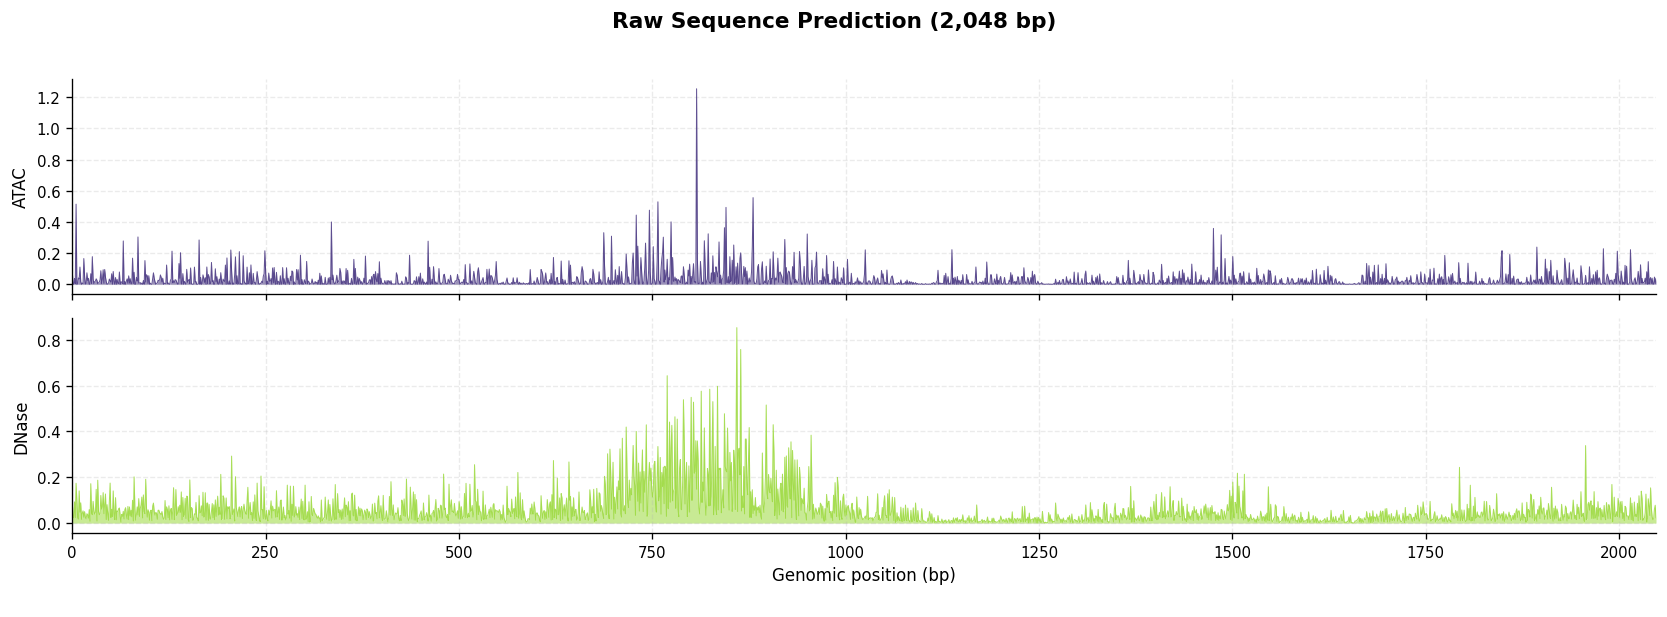

In [ ]:
# 📈 Plot sequence predictions
plot_tracks(
    predictions=seq_result.result.get("predictions", {}),
    track_keys=["atac", "dnase"],
    output_start=seq_result.interval_start,
    output_end=seq_result.interval_end,
    labels=["ATAC", "DNase"],
    title="Raw Sequence Prediction (2,048 bp)",
)

---
## 📏 4. Variant Scoring

Score a variant using AlphaGenome's recommended variant scorers. Returns a tidy table of scores (one row per scorer–track–gene combination).

Uses the same variant as **Figure 3c** (`chr21:46,126,238 G>C` in *COL6A2*).

### Configuration options:
- 🧪 **`variant_scorers`** — Scorer names from `RECOMMENDED_VARIANT_SCORERS` (e.g. `RNA_SEQ`, `ATAC`, `SPLICE_SITES`, …). `None` uses all recommended scorers.
- 🐭 **`organism`** — `human` or `mouse`

In [ ]:
score_variant_inputs = AlphaGenomeScoreVariantInput(
    chromosome="chr21",
    interval_start=45_601_950,
    interval_end=46_650_526,
    variant_position=46_126_238,
    reference_bases="G",
    alternate_bases="C",
)

score_variant_config = AlphaGenomeScoreVariantConfig(
    variant_scorers=["RNA_SEQ", "SPLICE_SITES"],
    organism="human",
)

score_variant_result = run_alphagenome_score_variant(
    score_variant_inputs, score_variant_config
)
print(f"Returned {len(score_variant_result.scores)} score records")
if score_variant_result.scores:
    df = pd.DataFrame(score_variant_result.scores)
    display(df.head(10))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 17722.41it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Returned 15124 score records


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,raw_score
0,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.099848
1,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,0.013318
2,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.270094
3,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.506179
4,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,0.066662
5,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000127,astrocyte,primary_cell,unknown,,encode,paired,False,0.004698
6,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,polyA plus RNA-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.016563
7,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000137,osteocyte,in_vitro_differentiated_cells,embryonic,,encode,single,False,0.017891
8,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000138,chondrocyte,in_vitro_differentiated_cells,embryonic,,encode,single,False,0.022392
9,"{'alternate_bases': 'C', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286082,ENSG00000286082,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,total RNA-seq,CL:0000169,type B pancreatic cell,in_vitro_differentiated_cells,embryonic,,encode,single,False,0.042645


---
## 📊 5. Interval Scoring

Score an interval using AlphaGenome's recommended interval scorers.

Uses the same region as **Figure 2a** (`chr19:10,587,331–11,635,907`).

### Configuration options:
- 🧪 **`interval_scorers`** — Scorer names from `RECOMMENDED_INTERVAL_SCORERS`. `None` uses all recommended scorers.
- 🐭 **`organism`** — `human` or `mouse`

In [ ]:
score_interval_inputs = AlphaGenomeScoreIntervalInput(
    chromosome="chr19",
    interval_start=10_587_331,
    interval_end=11_635_907,
)

score_interval_config = AlphaGenomeScoreIntervalConfig(
    interval_scorers=None,
    organism="human",
)

score_interval_result = run_alphagenome_score_interval(
    score_interval_inputs, score_interval_config
)
print(f"Returned {len(score_interval_result.scores)} score records")
if score_interval_result.scores:
    df = pd.DataFrame(score_interval_result.scores)
    display(df.head(10))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 80145.94it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Returned 4356 score records


,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,interval_scorer,track_name,...,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,raw_score
0,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000047 polyA plus RNA-seq,...,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,1.785927
1,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000062 total RNA-seq,...,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,0.265110
2,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000084 polyA plus RNA-seq,...,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.425308
3,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000084 total RNA-seq,...,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.691335
4,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000115 total RNA-seq,...,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,1.124342
5,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000127 total RNA-seq,...,total RNA-seq,CL:0000127,astrocyte,primary_cell,unknown,,encode,paired,False,0.620933
6,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000134 polyA plus RNA-seq,...,polyA plus RNA-seq,CL:0000134,mesenchymal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.846590
7,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000137 total RNA-seq,...,total RNA-seq,CL:0000137,osteocyte,in_vitro_differentiated_cells,embryonic,,encode,single,False,0.924274
8,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000138 total RNA-seq,...,total RNA-seq,CL:0000138,chondrocyte,in_vitro_differentiated_cells,embryonic,,encode,single,False,0.756436
9,"{'chromosome': 'chr19', 'end': 11635907, 'info...",ENSG00000127616,SMARCA4,protein_coding,+,None,None,RNA_SEQ,"GeneMaskScorer(requested_output=RNA_SEQ, width...",CL:0000169 total RNA-seq,...,total RNA-seq,CL:0000169,type B pancreatic cell,in_vitro_differentiated_cells,embryonic,,encode,single,False,1.229275


---
## 🔬 6. In-Silico Mutagenesis (ISM)

Mutate every position in a small sub-interval and score each mutation. Uses a **10 bp** window around the **Figure 3c** variant.

### Configuration options:
- 🧪 **`variant_scorers`** — Scorer names (same as variant scoring)
- 🐭 **`organism`** — `human` or `mouse`

In [ ]:
ism_inputs = AlphaGenomeScoreISMInput(
    chromosome="chr21",
    interval_start=45_601_950,
    interval_end=46_650_526,
    ism_interval_start=46_126_233,
    ism_interval_end=46_126_243,  # 10 bp window around variant
)

ism_config = AlphaGenomeScoreISMConfig(
    variant_scorers=["SPLICE_SITES"],
    organism="human",
)

ism_result = run_alphagenome_score_ism_variants(ism_inputs, ism_config)
print(f"Returned {len(ism_result.scores)} score records")
if ism_result.scores:
    df = pd.DataFrame(ism_result.scores)
    display(df.head(10))

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 18236.10it/s]
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/daniel.guo/bio-programming/.venvs/alphagenome_env/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
100%|██████████| 30/30 [01:56<00:00,  3.89s/it]


Returned 2280 score records


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,raw_score
0,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000286594,ENSG00000286594,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.002930
1,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000183570,PCBP3,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.111328
2,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000276633,ENSG00000276633,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.005737
3,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000280604,ENSG00000280604,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.025391
4,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000274248,ENSG00000274248,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.001343
5,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000142156,COL6A1,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.054688
6,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000224413,ENSG00000224413,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.022217
7,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000228235,ENSG00000228235,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.001587
8,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000226115,ENSG00000226115,lncRNA,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.005859
9,"{'alternate_bases': 'A', 'chromosome': 'chr21'...","{'chromosome': 'chr21', 'end': 46650526, 'info...",ENSG00000142173,COL6A2,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,donor,+,0.038086


---
## 💾 7. Export Results

Save prediction and scoring outputs to the local example output directory.

### Supported formats:
- 📄 **JSON** / **NumPy** for prediction outputs (`AlphaGenomePredictOutput`)
- 📊 **JSON** / **CSV** for scoring outputs (`AlphaGenomeScoreOutput`)

Example export code (not executed — outputs are very large):

```python
interval_result.export("example_output/alphagenome_predict_interval", file_format="json")
variant_result.export("example_output/alphagenome_predict_variant", file_format="json")
seq_result.export("example_output/alphagenome_predict_sequence", file_format="json")
score_variant_result.export("example_output/alphagenome_score_variant", file_format="csv")
score_interval_result.export("example_output/alphagenome_score_interval", file_format="csv")
ism_result.export("example_output/alphagenome_score_ism", file_format="csv")
```